In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42

import os
from raas.utils import calculate_rolling_rate, calculate_rolling_rate_ewma
from raas.simulation import Simulator

In [2]:
window_duration = 1000

policy_prefixes = {
    'sim_oracle_':          'Oracle',
    'sim_online_':          'Online Learning',
    'sim_myopic_heuristic_': 'Myopic Heuristic',
    'sim_fully_myopic_':    'Fully Myopic',
}

policy_dfs = {name: [] for name in policy_prefixes.values()}

for file in sorted(os.listdir('../data')):
    if not file.endswith('.pkl'):
        continue
    for prefix, label in policy_prefixes.items():
        if file.startswith(prefix):
            sim = Simulator.load('../data/'+file[:-4])
            df = pd.DataFrame(sim.history)
            df['net_profit'] = df['profit'] + df['loss']
            df['profit_rate'] = calculate_rolling_rate(df, 'calendar_time', 'net_profit', window_duration)
            policy_dfs[label].append(df)
            break

for label, dfs in policy_dfs.items():
    print(f'{label}: {len(dfs)} runs')

Oracle: 100 runs
Online Learning: 100 runs
Myopic Heuristic: 100 runs
Fully Myopic: 100 runs


In [3]:
min_time = 1000
max_time = 200000
common_time_grid = np.linspace(min_time, max_time, 500)

policy_stats = {}  # label -> (mean, std)

# col = 'profit_rate_ewma'
col = 'profit_rate'
# col = 'profit_rate_bc'

for label, dfs in policy_dfs.items():
    resampled = []
    for sim_df in dfs:
        rate = np.interp(common_time_grid, sim_df['calendar_time'], sim_df[col])
        resampled.append(rate)
    mat = np.vstack(resampled)
    policy_stats[label] = (np.mean(mat, axis=0), 2 * np.std(mat, axis=0, ddof=1) / np.sqrt(mat.shape[0]))

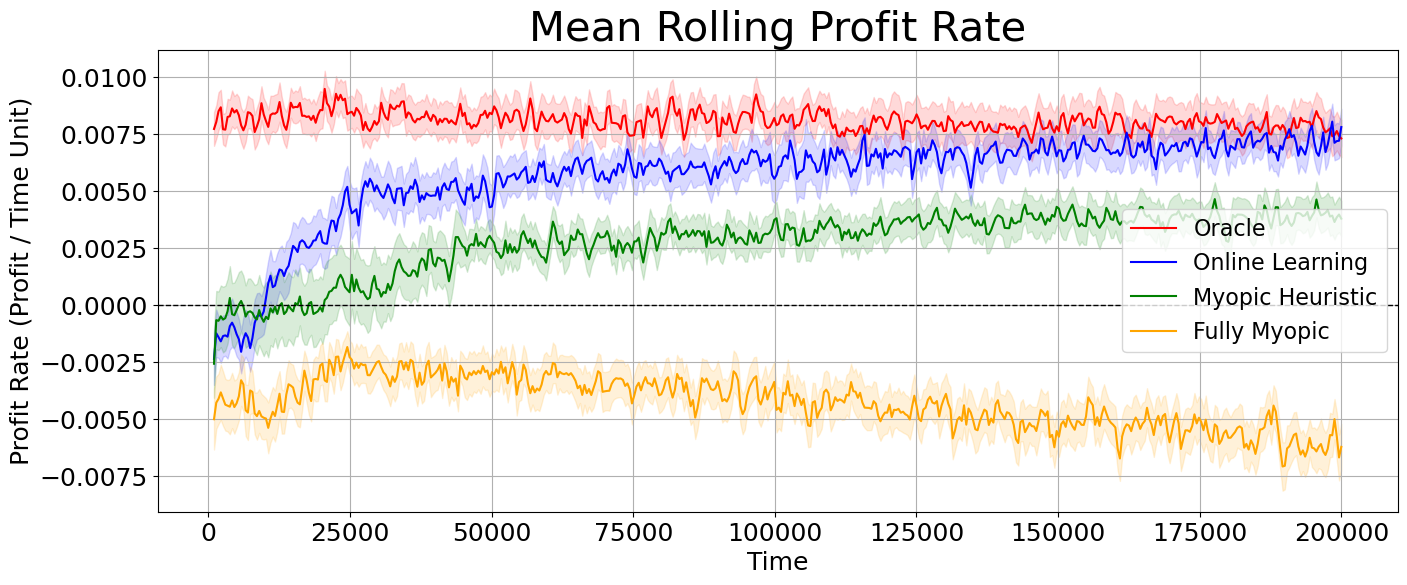

In [10]:
colors = {
    'Oracle':            'red',
    'Online Learning':   'blue',
    'Myopic Heuristic':  'green',
    'Fully Myopic':      'orange',
}

plt.figure(figsize=(16, 6))

for label, (mean, std) in policy_stats.items():
    c = colors[label]
    plt.plot(common_time_grid, mean, label=label, color=c)
    plt.fill_between(
        common_time_grid,
        mean - std,
        mean + std,
        color=c,
        alpha=0.15,
    )

plt.xlabel('Time', fontsize=18)
plt.ylabel('Profit Rate (Profit / Time Unit)', fontsize=18)
# plt.ylim(top=0.015, bottom=-0.015)

# plt.xscale('log')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Mean Rolling Profit Rate', fontsize=30)
plt.legend(fontsize=16)

plt.grid(True)
plt.savefig(f'../figures/profit_rate_comparison_max_{max_time}.pdf', bbox_inches='tight')
plt.show()